Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

ROC AUC: 1.0


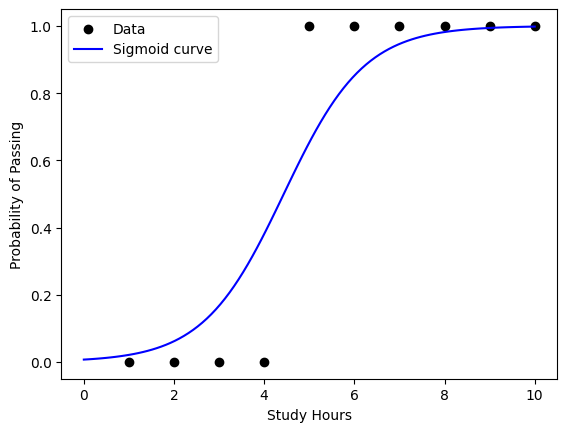

Intercept: [-4.9619827]
Coefficients: [[1.11882385]]
Odds ratio for 1 extra hour: 3.0612516002403796


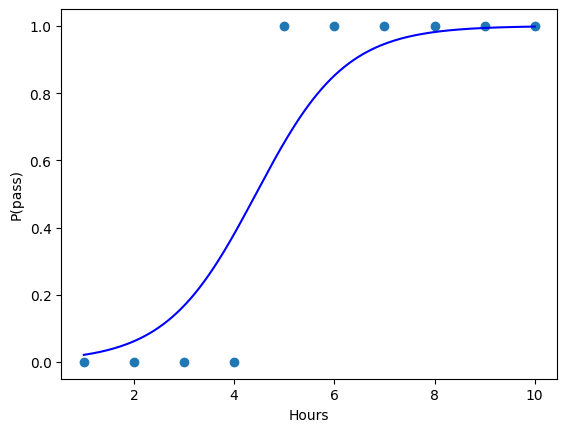

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Simulated dataset: hours studied vs pass/fail
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([0,0,0,0,1,1,1,1,1,1])  # 0 = Fail, 1 = Pass

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1] 
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
# Plot sigmoid curve
X_range = np.linspace(0, 10, 100).reshape(-1,1)
y_prob = log_model.predict_proba(X_range)[:,1]

plt.scatter(X, y, color="black", label="Data")
plt.plot(X_range, y_prob, color="blue", label="Sigmoid curve")
plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")
plt.legend()
plt.show()

#another plot for ROC-AUC-sigmoid||interpretation of coefficients
print("Intercept:", log_model.intercept_)
print("Coefficients:", log_model.coef_)

odds_ratio = np.exp(log_model.coef_[0][0])
print("Odds ratio for 1 extra hour:", odds_ratio)

X_range = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
y_prob_range = log_model.predict_proba(X_range)[:,1]
plt.scatter(X, y)
plt.plot(X_range, y_prob_range, color='blue')
plt.xlabel("Hours"); plt.ylabel("P(pass)")
plt.show()

#Thresholding & business decision
threshold = 0.4
y_pred_custom = (y_prob >= threshold).astype(int)
